<a id='home'></a>
### purpose

validate (calculate kendall's tau) between off set and fitness in the common gardens on the spatially continuous landscape

### outline

1. [get pop data](#popdata)
1. [get fitness](#fitness)
1. [get offsets](#offsets)
1. [validate predictions](#validate)
1. [create figures](#figs)
    1. [histograms](#histograms)
    1. [scatterplots](#scatterplots)
    1. [heatmaps](#heat)
    1. [boxplots](#boxplots)
1. [compare $GF_{geno,ind(ind-env)}$ to $GF_{geno,ind(pop-env)}$](#all)
1. [compare performance of marker sets](#markers)
1. [save](#save)

    - this saved file (validation.txt) is also available in the archive in the /data/spatially_continuous directory

In [1]:
from pythonimports import *
import myfigs as mf

import runtime_API as rt
import MVP_03_validate_gradient_forests as mvp03
import MVP_06_validate_RONA as mvp06
import MVP_summary_functions as mvp

import seaborn as sns
import matplotlib as mpl
import matplotlib.lines as mlines
from matplotlib.colors import colorConverter
import matplotlib.patches as mpatches
import itertools as it

outerdir = '/work/lotterhos/brandon/continuous_space_runtime'

# continuous space sims directory
tdir = '/home/b.lind/offsets/run_20220919_tutorial/tutorial'

# directories with files
training_dir = f'{outerdir}/gradient_forests/training/training_files'
fitting_dir = f'{outerdir}/gradient_forests/fitting'
garden_dir = f'{fitting_dir}/garden_files'

# where to save files
fitness_dir = f'{outerdir}/fitness_mats'
validation_dir = makedir(op.join(tdir, 'gradient_forests/validation'))

# # parallel engines
# lview, dview = get_client(cluster_id='1737737146-7vbv', profile='lotterhos')

t0 = dt.now()  # notebook timer

rt.latest_commit()
session_info.show()

#########################################################
Today:	February 17, 2025 - 12:18:08 EST
python version: 3.8.5
conda env: mvp_env

Current commit of pythonimports:
commit 6a767410e7b569adbf9df526de108f22ef50aad8  
Author: Brandon Lind <lind.brandon.m@gmail.com>  
Date:   Wed Mar 6 13:42:13 2024 -0700

Current commit of MVP_offsets:
commit 5ce82f4d655645237a0f4026fa32e220226dc373  
Author: Brandon Lind <lind.brandon.m@gmail.com>  
Date:   Thu May 16 13:02:58 2024 -0400

Current commit of MVP_runtime:
commit 16ad2278e7a75e265cfde7aec24292ffe9742a74  
Author: Brandon Lind <lind.brandon.m@gmail.com>  
Date:   Tue Jan 28 15:16:30 2025 -0500
#########################################################



<a id='popdata'></a>
# get pop data

[top](#home)

In [2]:
inds = pd.read_table(
    '/work/lotterhos/brandon/continuous_space_runtime/individual_data.txt',
)

inds

,ind_index,x,y,phenotype1_mat,phenotype2_MTWetQ,phenotype3_MTDQ,phenotype4_PDM,phenotype5_PwarmQ,phenotype6_PWM,env1_mat,env2_MTWetQ,env3_MTDQ,env4_PDM,env5_PwarmQ,env6_PWM,samp,subpopID
0,33,0.406184,0.233272,0.737967,-0.191421,0.142992,-0.131894,-0.452497,-0.541651,0.762432,-0.162238,0.261281,-0.332078,-0.471502,-0.477821,25_33,25
1,34,0.425697,0.837158,-0.274081,-0.428332,-0.012880,0.221058,0.229296,0.066597,-0.339330,-0.407667,-0.058296,0.288030,0.198810,0.017680,85_34,85
2,44,0.671673,0.581744,-0.676326,0.086629,-0.470671,0.218813,0.260098,-0.103465,-0.567733,0.090928,-0.414353,0.234899,0.230255,-0.053511,57_44,57
3,45,0.017466,0.329922,-0.283221,-0.403942,-0.333718,-0.200554,-0.345915,-0.410001,-0.245860,-0.200759,-0.267455,-0.265260,-0.389828,-0.458979,31_45,31
4,46,0.069744,0.121221,0.057616,-0.303201,0.731600,0.195679,-0.367110,0.196296,-0.121500,-0.306379,0.702858,0.211275,-0.352307,0.212751,11_46,11
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,8575,0.117890,0.278449,-0.070241,-0.367056,-0.061876,-0.308041,-0.468111,-0.508108,0.476928,-0.216205,0.401987,-0.377651,-0.607663,-0.374126,22_8575,22
996,8580,0.464067,0.792001,-0.050435,-0.342693,0.128758,0.107181,-0.061796,-0.081682,-0.320404,-0.411335,-0.038372,0.238443,0.145508,-0.007439,75_8580,75
997,8582,0.158645,0.682325,0.354088,0.493751,0.064744,-0.243331,-0.164916,-0.244379,0.225111,0.401138,-0.016827,-0.088830,-0.017708,-0.215783,62_8582,62
998,8585,0.894104,0.757964,-0.009027,0.424444,-0.575177,-0.514613,0.586778,0.266235,-0.028901,0.372221,-0.533756,-0.467916,0.559185,0.267799,79_8585,79


In [3]:
# get grid locations of each garden to use in heatmaps
# note that these aren't the actual location of the climate used in the gardens
_, locations, __ = mvp06.get_pop_data(mvp.slimdir, '1231234')

locations


Reading in info for subsampled individuals ...


,lon,lat
subpopID,,
1,1.0,1.0
2,2.0,1.0
3,3.0,1.0
4,4.0,1.0
5,5.0,1.0
...,...,...
96,6.0,10.0
97,7.0,10.0
98,8.0,10.0


<a id='fitness'></a>
# get fitness

created in 01_estimate_fitness.ipynb

[top](#home)

In [4]:
fitness_files = fs(fitness_dir, startswith='tutorial', endswith='.txt')

assert len(fitness_files) == 100

fitness_files[0]

'/work/lotterhos/brandon/continuous_space_runtime/fitness_mats/tutorial_1.txt'

In [5]:
dfs = []
for f in pbar(fitness_files):
    seed, outlier_clim = op.basename(f).replace('.txt', '').split("_")
    df = pd.read_table(f)  # 1-row, npop columns
    df.index = [outlier_clim]
    dfs.append(df)
    
fitness = pd.concat(dfs).reset_index().astype({'index' : int}).sort_values(by='index')

fitness.index = fitness['index'].tolist()
fitness.pop('index')

fitness

100%|███████████████| 100/100 [00:02<00:00, 39.49it/s]


,25_33,85_34,57_44,31_45,11_46,22_64,47_65,10_72,20_85,64_106,100_119,76_127,11_132,23_164,18_173,29_175,49_194,67_198,6_207,61_215,22_216,47_221,29_224,22_230,9_236,67_254,52_255,64_261,30_268,42_269,1_271,96_280,84_293,19_306,78_309,77_314,34_338,92_348,66_352,63_359,66_382,79_385,40_386,51_397,50_404,36_405,15_412,16_423,26_437,54_438,...,83_8163,7_8169,1_8172,75_8187,33_8217,43_8222,95_8228,40_8229,23_8231,23_8242,97_8252,76_8286,15_8311,64_8326,91_8330,79_8346,12_8351,93_8359,39_8360,62_8367,73_8371,24_8392,98_8394,39_8402,84_8409,75_8417,97_8418,59_8432,43_8446,3_8456,47_8458,99_8462,37_8468,60_8484,58_8500,32_8503,39_8509,45_8516,48_8533,57_8534,55_8535,63_8536,26_8547,45_8559,68_8564,22_8575,75_8580,62_8582,79_8585,78_8590
1,0.515120,0.629394,0.391132,0.445775,0.914052,0.653387,0.646495,0.692600,0.541038,0.754496,0.339901,0.444621,0.695847,0.519039,0.828569,0.493857,0.460520,0.686715,0.645799,0.492650,0.655309,0.773413,0.530306,0.655309,0.828569,0.466340,0.480500,0.765004,0.508249,0.410530,0.988822,0.545878,0.649216,0.474823,0.394692,0.431491,0.541283,0.578675,0.632584,0.698270,0.632584,0.478368,0.472253,0.436936,0.472253,0.820122,0.570782,0.799936,0.803550,0.665105,...,0.642307,0.845942,0.974128,0.615396,0.471031,0.499594,0.707139,0.666928,0.496706,0.477771,0.459048,0.630283,0.642003,0.761429,0.552331,0.402566,0.811028,0.641666,0.460520,0.584532,0.705264,0.383429,0.485955,0.438077,0.649216,0.615396,0.451184,0.356118,0.534473,0.809931,0.867853,0.472843,0.589207,0.520398,0.391132,0.521896,0.493857,0.613319,0.775248,0.535861,0.778430,0.784841,0.842294,0.746161,0.391132,0.491407,0.700836,0.541927,0.348332,0.413359
2,0.652315,0.724538,0.480333,0.591995,0.994106,0.800784,0.652029,0.815080,0.627634,0.772519,0.363942,0.528808,0.825700,0.666736,0.909071,0.591078,0.549500,0.784465,0.768462,0.631147,0.802948,0.806058,0.627153,0.802948,0.909071,0.554787,0.596388,0.846437,0.592503,0.531779,0.955207,0.626084,0.713457,0.567821,0.463452,0.512829,0.687878,0.667176,0.745990,0.744892,0.745990,0.525277,0.553251,0.562404,0.553251,0.841504,0.720533,0.877711,0.860646,0.793717,...,0.671946,0.854557,0.910144,0.691541,0.605948,0.616334,0.824381,0.741508,0.648392,0.577634,0.508506,0.746633,0.788405,0.860215,0.646487,0.437844,0.940030,0.697832,0.549500,0.672791,0.781014,0.485089,0.522867,0.529168,0.713457,0.691541,0.535908,0.436740,0.658305,0.887194,0.830467,0.509610,0.633293,0.578019,0.480333,0.683733,0.591078,0.726690,0.894696,0.644062,0.864499,0.845406,0.888175,0.849646,0.480333,0.656887,0.827154,0.646440,0.381667,0.481466
3,0.916310,0.697026,0.518107,0.799805,0.855553,0.990176,0.490796,0.918314,0.645842,0.623859,0.410932,0.577454,0.917755,0.951924,0.715549,0.667308,0.605844,0.749791,0.878750,0.861937,0.991311,0.665776,0.693196,0.991311,0.715549,0.580314,0.820868,0.803339,0.612848,0.802541,0.705400,0.682139,0.626240,0.589578,0.513420,0.551775,0.900065,0.727346,0.755319,0.615644,0.755319,0.537112,0.575211,0.815657,0.575211,0.690508,0.943910,0.888168,0.775082,0.926785,...,0.557658,0.696634,0.643235,0.632114,0.896444,0.821612,0.835712,0.745934,0.945494,0.774779,0.550566,0.760646,0.970527,0.816141,0.758508,0.471999,0.839799,0.615028,0.605844,0.776936,0.681001,0.737563,0.517539,0.609627,0.626240,0.632114,0.622387,0.455227,0.865813,0.752694,0.624166,0.516127,0.534934,0.634919,0.518107,0.916665,0.667308,0.781250,0.908572,0.704373,0.822436,0.773926,0.794644,0.893134,0.518107,0.908305,0.865099,0.809845,0.441670,0.511986
4,0.898202,0.533632,0.475902,0.754692,0.612135,0.905146,0.328081,0.771799,0.561617,0.423040,0.441210,0.553734,0.788215,0.953234,0.475369,0.638344,0.578611,0.571485,0.751393,0.940323,0.891648,0.469184,0.663367,0.891648,0.475369,0.537353,0.934122,0.626375,0.547696,0.964499,0.479714,0.667355,0.450979,0.463073,0.498924,0.526456,0.858576,0.704775,0.592837,0.427818,0.592837,0.510060,0.528309,0.951674,0.528309,0.483410,0.857041,0.710493,0.580040,0.797255,...,0.397819,0.484488,0.431999,0.472038,0.963308,0.912996,0.650035,0.661214,0.955155,0.86

In [6]:
pd.read_table('/work/lotterhos/brandon/continuous_space_runtime/fitness_mats/tutorial_5.txt')

,25_33,85_34,57_44,31_45,11_46,22_64,47_65,10_72,20_85,64_106,100_119,76_127,11_132,23_164,18_173,29_175,49_194,67_198,6_207,61_215,22_216,47_221,29_224,22_230,9_236,67_254,52_255,64_261,30_268,42_269,1_271,96_280,84_293,19_306,78_309,77_314,34_338,92_348,66_352,63_359,66_382,79_385,40_386,51_397,50_404,36_405,15_412,16_423,26_437,54_438,...,83_8163,7_8169,1_8172,75_8187,33_8217,43_8222,95_8228,40_8229,23_8231,23_8242,97_8252,76_8286,15_8311,64_8326,91_8330,79_8346,12_8351,93_8359,39_8360,62_8367,73_8371,24_8392,98_8394,39_8402,84_8409,75_8417,97_8418,59_8432,43_8446,3_8456,47_8458,99_8462,37_8468,60_8484,58_8500,32_8503,39_8509,45_8516,48_8533,57_8534,55_8535,63_8536,26_8547,45_8559,68_8564,22_8575,75_8580,62_8582,79_8585,78_8590
1,0.906244,0.642585,0.586931,0.836827,0.676211,0.938528,0.422306,0.851921,0.674475,0.518919,0.507638,0.662625,0.869942,0.933596,0.55918,0.747699,0.689882,0.676058,0.843179,0.972411,0.924384,0.569839,0.770627,0.924384,0.55918,0.650014,0.941399,0.720848,0.658577,0.944935,0.542868,0.75763,0.557466,0.576405,0.600685,0.634732,0.933434,0.791943,0.697692,0.52993,0.697692,0.595489,0.636056,0.956921,0.636056,0.578968,0.910696,0.769575,0.677349,0.866056,...,0.498385,0.572207,0.498019,0.581601,0.946708,0.939669,0.744776,0.758521,0.939178,0.828266,0.634601,0.715173,0.920423,0.713454,0.850944,0.552154,0.670239,0.553184,0.689882,0.852423,0.598731,0.834694,0.562246,0.704879,0.557466,0.581601,0.734853,0.509911,0.947911,0.627443,0.498721,0.575447,0.483066,0.711523,0.586931,0.926624,0.747699,0.746132,0.814575,0.731361,0.710126,0.701065,0.680299,0.83492,0.586931,0.918221,0.797933,0.909404,0.546494,0.584831


In [7]:
pd.read_table('/work/lotterhos/brandon/continuous_space_runtime/fitness_mats/tutorial_100.txt')

,25_33,85_34,57_44,31_45,11_46,22_64,47_65,10_72,20_85,64_106,100_119,76_127,11_132,23_164,18_173,29_175,49_194,67_198,6_207,61_215,22_216,47_221,29_224,22_230,9_236,67_254,52_255,64_261,30_268,42_269,1_271,96_280,84_293,19_306,78_309,77_314,34_338,92_348,66_352,63_359,66_382,79_385,40_386,51_397,50_404,36_405,15_412,16_423,26_437,54_438,...,83_8163,7_8169,1_8172,75_8187,33_8217,43_8222,95_8228,40_8229,23_8231,23_8242,97_8252,76_8286,15_8311,64_8326,91_8330,79_8346,12_8351,93_8359,39_8360,62_8367,73_8371,24_8392,98_8394,39_8402,84_8409,75_8417,97_8418,59_8432,43_8446,3_8456,47_8458,99_8462,37_8468,60_8484,58_8500,32_8503,39_8509,45_8516,48_8533,57_8534,55_8535,63_8536,26_8547,45_8559,68_8564,22_8575,75_8580,62_8582,79_8585,78_8590
1,0.437653,0.63588,0.699231,0.554735,0.408177,0.508002,0.516118,0.566602,0.727854,0.549888,0.99814,0.806704,0.610836,0.404033,0.416594,0.776374,0.790499,0.625868,0.57739,0.619537,0.489979,0.583978,0.781404,0.489979,0.416594,0.747867,0.641631,0.619082,0.75548,0.523956,0.419598,0.87396,0.591368,0.545877,0.851571,0.808199,0.576877,0.77728,0.630783,0.57693,0.630783,0.941894,0.775622,0.613775,0.775622,0.55313,0.493927,0.500648,0.617038,0.581924,...,0.617778,0.509629,0.442729,0.629939,0.526694,0.671748,0.585304,0.801836,0.430104,0.465956,0.960477,0.647221,0.529679,0.581368,0.805691,0.98434,0.332216,0.629335,0.790499,0.776179,0.565068,0.405827,0.93549,0.798507,0.591368,0.629939,0.888641,0.615586,0.608926,0.504335,0.529098,0.955003,0.56307,0.937617,0.699231,0.547783,0.776374,0.675601,0.582852,0.723117,0.570634,0.61338,0.577734,0.643718,0.699231,0.503379,0.605902,0.697541,0.997573,0.850718


<a id='offsets'></a>
# get offsets

[top](#home)

In [8]:
offset_files = fs(f'{fitting_dir}/fitting_outfiles', endswith='.txt')

assert len(offset_files) == 800

len(offset_files)

800

In [9]:
pd.read_table(offset_files[0]).T

,25_33,85_34,57_44,31_45,11_46,22_64,47_65,10_72,20_85,64_106,100_119,76_127,11_132,23_164,18_173,29_175,49_194,67_198,6_207,61_215,22_216,47_221,29_224,22_230,9_236,67_254,52_255,64_261,30_268,42_269,1_271,96_280,84_293,19_306,78_309,77_314,34_338,92_348,66_352,63_359,66_382,79_385,40_386,51_397,50_404,36_405,15_412,16_423,26_437,54_438,...,83_8163,7_8169,1_8172,75_8187,33_8217,43_8222,95_8228,40_8229,23_8231,23_8242,97_8252,76_8286,15_8311,64_8326,91_8330,79_8346,12_8351,93_8359,39_8360,62_8367,73_8371,24_8392,98_8394,39_8402,84_8409,75_8417,97_8418,59_8432,43_8446,3_8456,47_8458,99_8462,37_8468,60_8484,58_8500,32_8503,39_8509,45_8516,48_8533,57_8534,55_8535,63_8536,26_8547,45_8559,68_8564,22_8575,75_8580,62_8582,79_8585,78_8590
offset,0.080649,0.067879,0.045738,0.070147,0.101917,0.079152,0.071457,0.067882,0.052639,0.067113,0.001934,0.040558,0.078177,0.086759,0.095086,0.047445,0.040632,0.068499,0.066667,0.05754,0.084501,0.069676,0.046556,0.082746,0.101709,0.041266,0.061584,0.066066,0.043453,0.071696,0.104012,0.033346,0.068892,0.072737,0.035942,0.03964,0.072108,0.041423,0.068883,0.067226,0.066166,0.020478,0.043752,0.055858,0.039415,0.069445,0.076752,0.072235,0.06959,0.067222,...,0.066722,0.070446,0.10276,0.068704,0.075824,0.057201,0.066772,0.039306,0.089049,0.07683,0.023755,0.050086,0.076997,0.068941,0.044618,0.005644,0.107945,0.064922,0.047329,0.04403,0.067469,0.069986,0.0207,0.042014,0.066866,0.069122,0.025197,0.036328,0.069901,0.110567,0.071445,0.016734,0.074252,0.028863,0.043273,0.076439,0.043741,0.07,0.071404,0.050411,0.067043,0.064653,0.068719,0.069789,0.042223,0.086985,0.068622,0.045203,0.007589,0.028974


In [10]:
op.basename(offset_files[0]).split("_")

['tutorial',
 'GF',
 'training',
 '10000',
 'ind',
 '100',
 'gradient',
 'forest',
 'offset.txt']

In [11]:
offset_rows = wrap_defaultdict(list, 2)
for f in pbar(offset_files):
    tutorial_str, GF_str, training_str, num_loci, level, gardenID, *args = op.basename(f).split("_")
    
    df = pd.read_table(f).T
    df.index = [int(gardenID)]
    
    offset_rows[num_loci][level].append(df)

100%|███████████████| 800/800 [00:02<00:00, 266.92it/s]


In [12]:
offset_dfs = defaultdict(dict)
for (num_loci, level), dfs in unwrap_dictionary(offset_rows):
    print(num_loci, level, len(dfs))
    df = pd.concat(dfs)
    df = df.loc[sorted(df.index)]
    
    offset_dfs[num_loci][level] = df
    
offset_dfs[num_loci][level]

10000 ind 100
10000 pop 100
20000 ind 100
20000 pop 100
5000 ind 100
5000 pop 100
500 ind 100
500 pop 100


,25_33,85_34,57_44,31_45,11_46,22_64,47_65,10_72,20_85,64_106,100_119,76_127,11_132,23_164,18_173,29_175,49_194,67_198,6_207,61_215,22_216,47_221,29_224,22_230,9_236,67_254,52_255,64_261,30_268,42_269,1_271,96_280,84_293,19_306,78_309,77_314,34_338,92_348,66_352,63_359,66_382,79_385,40_386,51_397,50_404,36_405,15_412,16_423,26_437,54_438,...,83_8163,7_8169,1_8172,75_8187,33_8217,43_8222,95_8228,40_8229,23_8231,23_8242,97_8252,76_8286,15_8311,64_8326,91_8330,79_8346,12_8351,93_8359,39_8360,62_8367,73_8371,24_8392,98_8394,39_8402,84_8409,75_8417,97_8418,59_8432,43_8446,3_8456,47_8458,99_8462,37_8468,60_8484,58_8500,32_8503,39_8509,45_8516,48_8533,57_8534,55_8535,63_8536,26_8547,45_8559,68_8564,22_8575,75_8580,62_8582,79_8585,78_8590
1,0.047890,0.054593,0.051222,0.067944,0.030097,0.049842,0.056434,0.047245,0.059622,0.042734,0.092472,0.056130,0.030097,0.063869,0.048592,0.061773,0.079780,0.082023,0.045306,0.069174,0.049842,0.056434,0.061773,0.049842,0.040143,0.082023,0.072236,0.042734,0.071019,0.072209,0.000000,0.075527,0.060428,0.055467,0.083303,0.087349,0.054193,0.050709,0.053741,0.044272,0.053741,0.078071,0.067836,0.072936,0.071479,0.037657,0.056155,0.034756,0.040319,0.042071,...,0.054158,0.024865,0.000000,0.053619,0.074766,0.063691,0.066629,0.067836,0.063869,0.063869,0.071082,0.056130,0.056155,0.042734,0.067934,0.078071,0.036292,0.052810,0.074920,0.070726,0.050762,0.081088,0.077874,0.074920,0.060428,0.053619,0.071082,0.087491,0.063691,0.046344,0.056434,0.089205,0.056059,0.073600,0.070821,0.061887,0.074920,0.040675,0.051626,0.051222,0.039326,0.044272,0.040319,0.040675,0.091365,0.049842,0.053619,0.070726,0.078071,0.083303
2,0.043296,0.045153,0.043967,0.056596,0.016883,0.039170,0.051360,0.037666,0.051121,0.037781,0.091174,0.046399,0.016883,0.056529,0.041228,0.053516,0.072231,0.073695,0.038260,0.061764,0.039170,0.051360,0.053516,0.039170,0.028360,0.073695,0.068160,0.037781,0.063832,0.066849,0.017239,0.069027,0.053771,0.045556,0.077090,0.079676,0.045762,0.046260,0.044693,0.040724,0.044693,0.074723,0.061187,0.065312,0.065340,0.036231,0.048488,0.030793,0.036331,0.035366,...,0.050783,0.022627,0.017239,0.044883,0.069828,0.057396,0.059199,0.061187,0.056529,0.056529,0.066483,0.046399,0.048488,0.037781,0.064275,0.074723,0.022273,0.049348,0.067093,0.067176,0.049385,0.076760,0.076611,0.067093,0.053771,0.044883,0.066483,0.080227,0.057396,0.036616,0.051360,0.088012,0.052684,0.068247,0.062936,0.052159,0.067093,0.033552,0.043956,0.043967,0.033223,0.040724,0.036331,0.033552,0.083557,0.039170,0.044883,0.067176,0.074723,0.077090
3,0.019906,0.049008,0.049585,0.039385,0.032419,0.014387,0.064259,0.045960,0.054351,0.044987,0.084590,0.047632,0.032419,0.021587,0.055407,0.046417,0.071919,0.075242,0.028395,0.044010,0.014387,0.064259,0.046417,0.014387,0.038153,0.075242,0.049702,0.044987,0.061649,0.046085,0.046344,0.065406,0.063039,0.045204,0.076269,0.080029,0.017998,0.052000,0.049335,0.046744,0.049335,0.070199,0.057178,0.044999,0.063111,0.048731,0.017250,0.028937,0.047035,0.029109,...,0.061994,0.045626,0.046344,0.050438,0.048282,0.035756,0.061277,0.057178,0.021587,0.021587,0.062125,0.047632,0.017250,0.044987,0.050976,0.070199,0.023352,0.059808,0.064902,0.051182,0.051108,0.054022,0.073417,0.064902,0.063039,0.050438,0.062125,0.081196,0.035756,0.000000,0.064259,0.083679,0.067952,0.065131,0.064573,0.025850,0.064902,0.030386,0.047331,0.049585,0.036200,0.046744,0.047035,0.030386,0.085068,0.014387,0.050438,0.051182,0.070199,0.076269
4,0.035641,0.071641,0.069289,0.046888,0.060558,0.037918,0.088453,0.063185,0.068275,0.067802,0.080392,0.064690,0.060558,0.018047,0.080746,0.057781,0.080041,0.085412,0.050273,0.033221,0.037918,0.088453,0.057781,0.037918,0.064536,0.085412,0.031262,0.067802,0.069827,0.026025,0.071708,0.069453,0.084974,0.066652,0.081256,0.086839,0.028641,0.069252,0.071187,0.066276,0.071187,0.070767,0.063157,0.029831,0.068907,0.073108,0.020294,0.052538,0.071647,0.051363,...,0.083586,0.071557,0.071708,0.073458,0.026005,0.022786,0.070698,0.063157,0.018047,0.01

<a id='validate'></a>
# validate predictions

[top](#home)

In [13]:
vmin = math.inf
vmax = -math.inf

validation = pd.DataFrame(
    columns=['num_loci', 'level', 'garden', 'score']
)

heatmaps = wrap_defaultdict(lambda: mvp03.blank_dataframe(), 2)
for (num_loci, level), offset in unwrap_dictionary(offset_dfs, progress_bar=True):
    if nrow(offset) != 100:
        print(ColorText(f'INCOMPLETE: {num_loci} {level}').fail().bold())
        continue

    corrs = offset.corrwith(fitness, axis=1, method='kendall')
    
    for subpopID, corr in corrs.items():
        lon, lat = locations.loc[subpopID]
        heatmaps[num_loci][level].loc[lon, lat] = corr
        
        if corr < vmin:
            vmin = corr
        if corr > vmax:
            vmax = corr
            
        validation.loc[nrow(validation), : ] = (num_loci,
                                                level,
                                                subpopID,
                                                corr)
        
validation['program'] = 'GF'
validation['level'] = validation['level'] + '-env'

validation = validation.astype({'score' : float})

validation

100%|███████████████| 4/4 [00:00<00:00,  5.17it/s]


,num_loci,level,garden,score,program
0,10000,ind-env,1,-0.728953,GF
1,10000,ind-env,2,-0.787002,GF
2,10000,ind-env,3,-0.690591,GF
3,10000,ind-env,4,-0.779857,GF
4,10000,ind-env,5,-0.765953,GF
...,...,...,...,...,...
795,500,pop-env,96,-0.693984,GF
796,500,pop-env,97,-0.708619,GF
797,500,pop-env,98,-0.696123,GF
798,500,pop-env,99,-0.726030,GF


<a id='figs'></a>
# make figures

[top](#home)

<a id='histograms'></a>
## histograms

[top](#home)

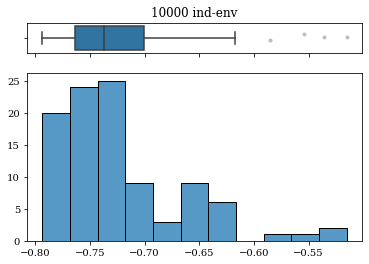

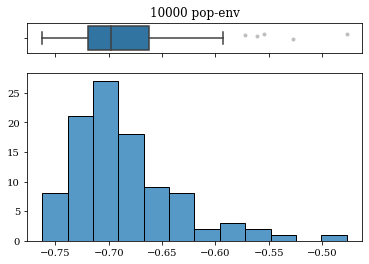

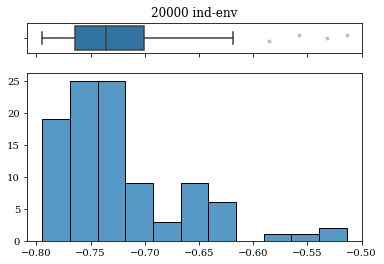

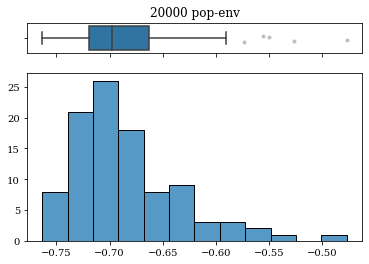

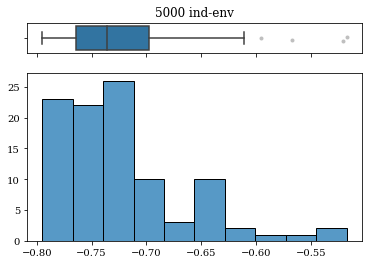

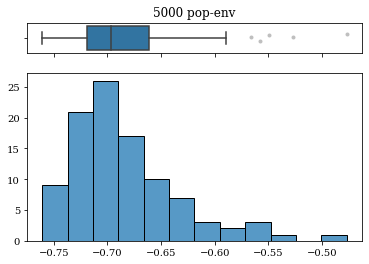

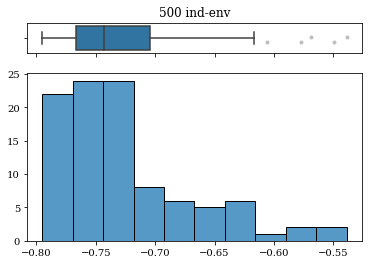

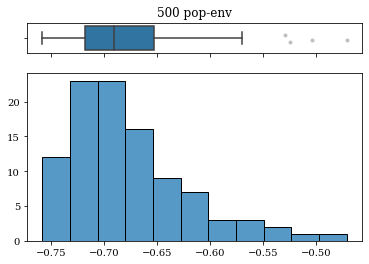

In [14]:
for num_loci in validation.num_loci.unique():
    for level in validation.level.unique():
        df = validation[(validation.num_loci == num_loci) & (validation.level == level)]
        
        if nrow(df) > 0:
            mf.histo_box(df.score, title=f'{num_loci} {level}')
        else:
            print(ColorText(f'INCOMPLETE: {num_loci} {level}').fail().bold())

<a id='scatterplots'></a>
## scatterplots

[top](#home)

Saved to:  /home/b.lind/offsets/run_20220919_tutorial/tutorial/gradient_forests/validation/pop-env_ind-env_comparison.pdf


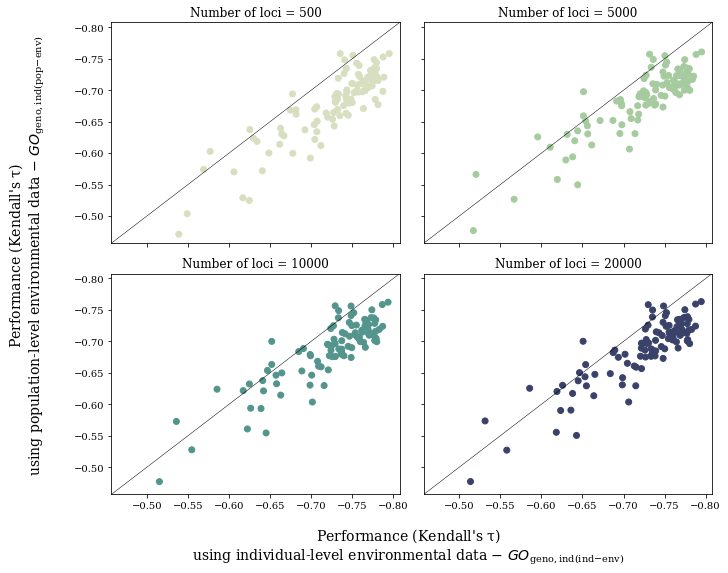

In [15]:
fig, axes = plt.subplots(nrows=2, ncols=2, sharex=True, sharey=True, figsize=(10, 8))

for num_loci, ax in zip(['500', '5000', '10000', '20000'], axes.flat):
    ind = validation[(validation.num_loci == num_loci) & (validation.level == 'ind-env')]
    pop = validation[(validation.num_loci == num_loci) & (validation.level == 'pop-env')]
    
    ax.scatter(ind.score, pop.score, color=[rt.boxplot_kwargs['palette'][num_loci] for x in ind.score])#c=rt.boxplot_kwargs['palette'][num_loci])
    
    mf.draw_xy(ax)
    
    ax.invert_yaxis()
    ax.invert_xaxis()
    
    ax.set_title(f'Number of loci = {num_loci}')
    
fig.supxlabel('%s\nusing individual-level environmental data $-$ $\it{GO}$$_{geno,ind (ind\u2212env)}$' % rt.perf_label,
              fontsize=14, ha='center', x=0.55)
fig.supylabel('%s\nusing population-level environmental data $-$ $\it{GO}$$_{geno,ind (pop\u2212env)}$' % rt.perf_label,
              fontsize=14, ha='center', y=0.55)
    
plt.tight_layout()

mf.save_pdf(f'{validation_dir}/pop-env_ind-env_comparison.pdf')

<a id='heat'></a>
## heat maps

[top](#home)

In [16]:
def show_heatmaps(vmin=None, vmax=None):
    axes = []
    for (num_loci, level), heatmap in unwrap_dictionary(heatmaps):
        g = sns.heatmap(heatmap,
                        vmin=vmin,
                        vmax=vmax,
                        cmap='viridis',
                        cbar_kws={'label': "Kendall's $\\tau$"})

        g.set(title=f'{num_loci} {level}-level envdata')

        g.figure.axes[-1].yaxis.label.set_size(15)
        
        g.figure.axes[1].invert_yaxis()

        plt.show()

        axes.append(g.figure.axes)
    
    return axes

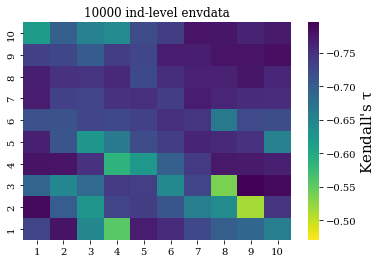

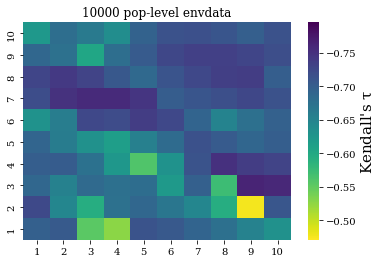

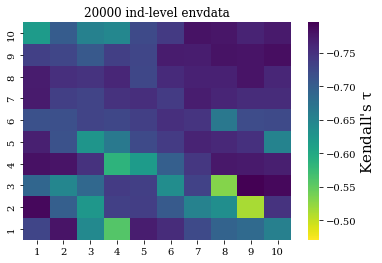

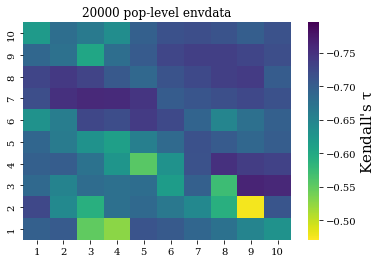

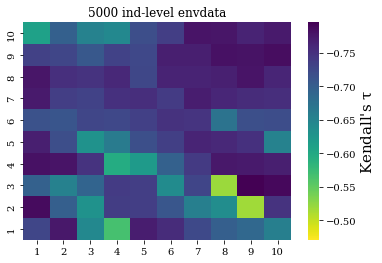

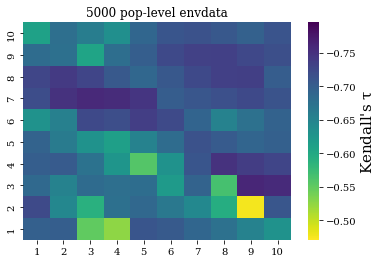

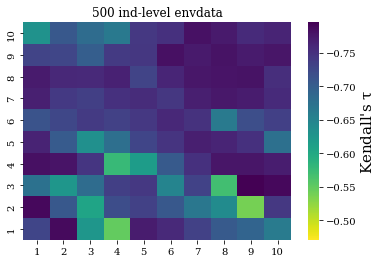

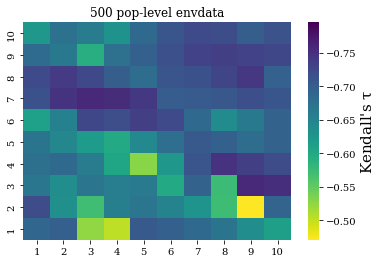

In [17]:
# heatmaps with common color bar
axes = show_heatmaps(vmin=vmin, vmax=vmax)

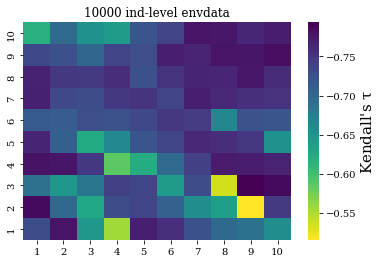

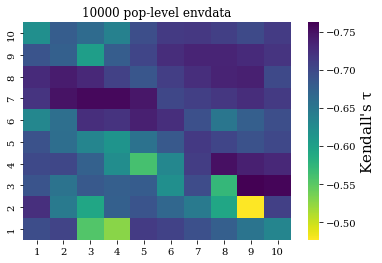

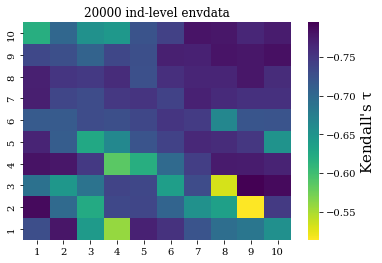

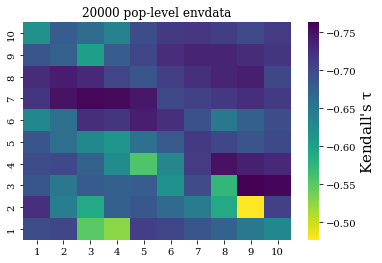

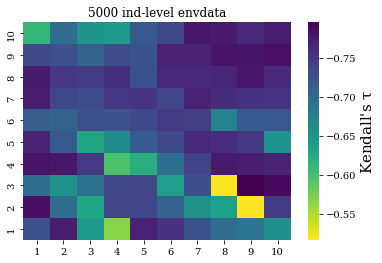

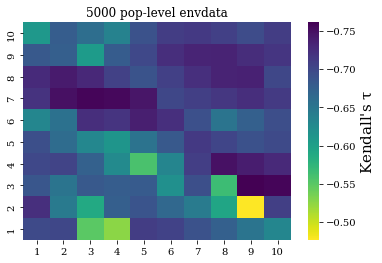

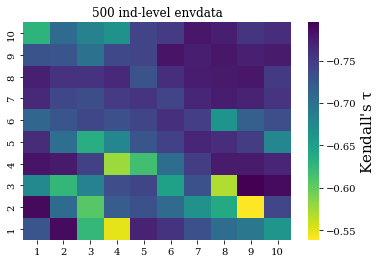

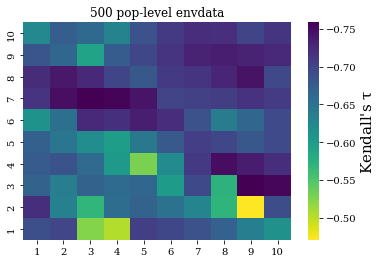

In [18]:
# heatmaps with unique color bar per heatmap
axes = show_heatmaps()

<a id='boxplots'></a>
## boxplots

[top](#home)

In [19]:
rt.boxplot_kwargs['palette'].update(
    {
        'ind-env' : 'cornflowerblue',
        'pop-env' : 'cornflowerblue',
    }
)

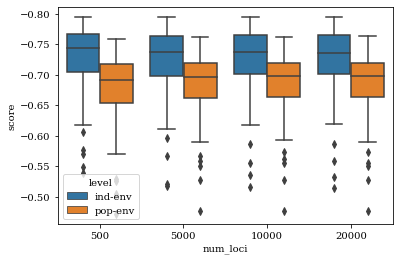

In [20]:
g = sns.boxplot(data=validation,
                x='num_loci',
                order=rt.hue_order['num_loci'] + ['20000'],
                hue='level',
                y='score',
#                 palette=mvp.boxplot_kwargs['palette']
               )

g.axes.invert_yaxis()

<a id='all'></a>
# compare $GF_{geno,ind(ind-env)}$ to $GF_{geno,ind(pop-env)}$

[top](#home)

In [21]:
# genotype-based models
validation.head()

,num_loci,level,garden,score,program
0,10000,ind-env,1,-0.728953,GF
1,10000,ind-env,2,-0.787002,GF
2,10000,ind-env,3,-0.690591,GF
3,10000,ind-env,4,-0.779857,GF
4,10000,ind-env,5,-0.765953,GF


In [22]:
# # read in allele frequency validation scores that uses pop-level envs
# pooled_val = pd.read_table('/home/b.lind/offsets/run_20220919_tutorial/gradient_forests/validation/tutorial_validation_scores.txt')
# pooled_val['num_loci'] = '26370'
# pooled_val['level'] = 'pop-env'
# pooled_val['program'] = 'GF'
# pooled_val = pooled_val[pooled_val.marker_set == 'all'].reset_index(drop=True)[['num_loci', 'level', 'garden', 'score', 'program', 'ind_or_pooled']]

# pooled_val

In [23]:
# # combine genotype-based and AF-based results
# validation['ind_or_pooled'] = 'ind'
# all_data = pd.concat([validation, pooled_val]).reset_index(drop=True)

# all_data

In [24]:
# from a newer version of pythonimports
def add_legend(ldict, markers='s', legendmarkerfacecolor='fill', markeredgecolor=None, title=None, ax=None,
               loc='center left', bbox_to_anchor=(0.95, 0.50), fontsize=11, ncol=1, add_handles=[],
               face_alpha=1, edge_alpha=1
              ):
    """Add a legend to `ax`.
    
    Parameters
    ----------
    ldict : dict
        key = value = label used in legend labels, value = color
    markers : dict | str
        if dict, use keys in ldict. If str, specify marker for all ldict.keys()
    legendmarkerfacecolor : 'fill' | str | tuple(R, G, B, [alpha])
        if 'fill', use color in ldict. Otherwise, specify another color. use with `face_alpha`.
    markeredgecolor : str | dict
        use with `edge_alpha`. if dict, keys are ldict.keys()
    title : str
        title for legend
    ax : e.g., matplotlib.axes._axes.Axes | cartopy.mpl.geoaxes.GeoAxes
    loc : str
        location of legend with respect to bbox_to_anchor location
    bbox_to_anchor : tuple
        Box that is used to position the legend in conjunction with *loc*.
    fontsize : int
        fontsize of legend. legend title is fontsize+1
    ncol : int
        the number of columns in the legend
    face_alpha : int | dict
        opacity of facecolor. if dict, keys are ldict.keys()
    edge_alpha : int | dict
        opacity of edgecolor. if dict, keys are ldict.keys()
    """    
    if ax is None:
        fig, ax = plt.subplots()
    else:
        fig = ax.get_figure()

    # get the things that go into the legend
    handles = []
    for label, color in ldict.items():
        marker = markers[label] if isinstance(markers, dict) else markers
        facealpha = face_alpha[label] if isinstance(face_alpha, dict) else face_alpha
        edgealpha = edge_alpha[label] if isinstance(edge_alpha, dict) else edge_alpha
        
        if legendmarkerfacecolor == 'fill':
            markerfacecolor = (*colorConverter.to_rgb(color), facealpha)
        else:
            markerfacecolor = (*colorConverter.to_rgb(legendmarkerfacecolor), facealpha)

        if markeredgecolor is None:
            medgecolor = (*colorConverter.to_rgb(color), edgealpha)
        elif isinstance(markeredgecolor, dict):
            medgecolor = (*colorConverter.to_rgb(markeredgecolor[label]), edgealpha)
        else:
            medgecolor = markeredgecolor

        handles.append(
#             mlines.Line2D([0], [0], marker=marker, color='none', markerfacecolor=markerfacecolor,
#                    markeredgecolor=medgecolor,
#                    label=label, markersize=fontsize)
            mpatches.Rectangle([0, 0], width=0, height=0, facecolor=color, label=label)
        )
    handles.extend(add_handles)

    # create a legend
    leg1 = fig.legend(
        handles=handles, fancybox=True, shadow=False, ncol=ncol, title=title, 
        facecolor='whitesmoke', loc=loc, bbox_to_anchor=bbox_to_anchor,
        prop=dict(family='serif', size=fontsize)
    )
    fig.add_artist(leg1)
    plt.setp(leg1.get_title(), family='serif', fontsize=fontsize+1)
    leg1.get_title().set_multialignment('center')
    
    return leg1

Saved to:  /home/b.lind/offsets/run_20220919_tutorial/tutorial/gradient_forests/validation/spatially_continuous_eval.pdf


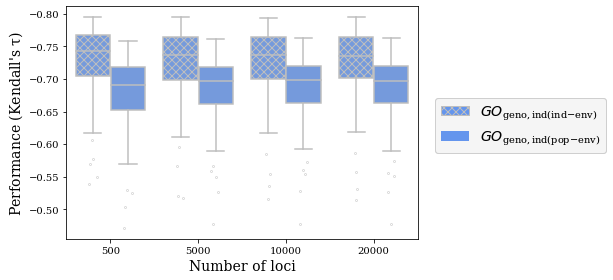

In [25]:
plt.rcParams.update({'font.family' : 'serif', 'mathtext.default': 'regular', 'hatch.color' : 'dimgray'})

g = sns.boxplot(#data=all_data,
                data=validation,
                x='num_loci',
#                 order=rt.hue_order['num_loci'] + ['20000', '26370'],
                order=rt.hue_order['num_loci'] + ['20000'],
                hue='level',
                y='score',
                **mvp.boxplot_kwargs
#                 palette=mvp.boxplot_kwargs['palette']
               )

g.legend().remove()

g.axes.invert_yaxis()

g.axes.set_xlabel('Number of loci', fontsize=14)
g.axes.set_ylabel(rt.perf_label, fontsize=14)

boxes = [patch for patch in g.patches if type(patch) == mpl.patches.PathPatch]
for i, box in enumerate(boxes):
    if i % 2 == 0 and i < 7:
        box.set_hatch('xxx')
        
# boxes[-1].set_facecolor('navy')

leg = add_legend(
    ldict = {
        '$\it{GO}$$_{geno,ind (ind\u2212env)}$' : 'cornflowerblue',
        '$\it{GO}$$_{geno,ind (pop\u2212env)}$' : 'cornflowerblue',
#         '$\\it{GO}$$_{AF,pop  (pop-env)}$' : 'navy'
    },
    ax=g.axes,
    fontsize=14,
    bbox_to_anchor=(1.0, 0.55)
)

rects = [x for x in leg.findobj() if type(x) == mpatches.Rectangle]

rects[0].set_hatch('xxx')
rects[0].set_edgecolor('#bebebe')

mvp.jitter_fliers(axes=[g.axes])

plt.tight_layout()

mf.save_pdf(f'{validation_dir}/spatially_continuous_eval.pdf')

In [26]:
formatclock(dt.now() - t0)

'0-00:00:14'

<a id='markers'></a>
# compare performance of marker sets

[top](#home)

In [27]:
validation.level.unique()

array(['ind-env', 'pop-env'], dtype=object)

In [28]:
validation.head()

,num_loci,level,garden,score,program
0,10000,ind-env,1,-0.728953,GF
1,10000,ind-env,2,-0.787002,GF
2,10000,ind-env,3,-0.690591,GF
3,10000,ind-env,4,-0.779857,GF
4,10000,ind-env,5,-0.765953,GF


In [29]:
ax_ids = {
    '500 5000' : (0, 0),
    '500 10000' : (1, 0),
    '500 20000' : (2, 0),
    
    '5000 10000' : (1, 1),
    '5000 20000' : (2, 1),
    
    '10000 20000' : (2, 2)
}

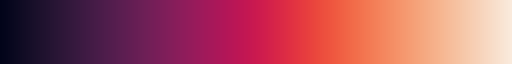

In [30]:
cmap = sns.color_palette('rocket', as_cmap=True)
norm = mpl.colors.Normalize(vmin=0.9961600144073539, vmax=1.0) # ran cell below for vmin from `all_cors`

# note, since I put colorbar on pooled, I could have just used `vmin=min(all_corrs)` in normalize function

cmap

Saved to:  /home/b.lind/offsets/run_20220919_tutorial/tutorial/gradient_forests/validation/ind-env_scatter_all-comparisons.pdf


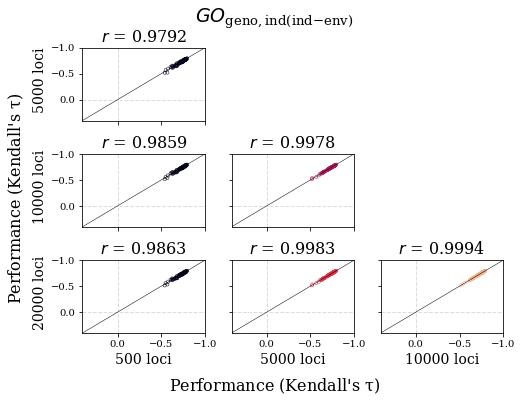

Saved to:  /home/b.lind/offsets/run_20220919_tutorial/tutorial/gradient_forests/validation/pop-env_scatter_all-comparisons.pdf


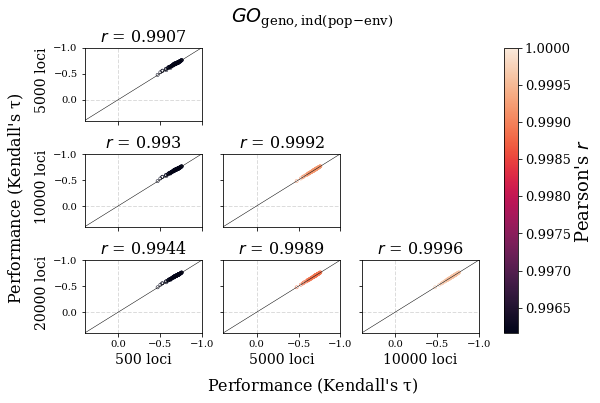

In [31]:
validation = validation.astype({'num_loci': int}).sort_values(by=['num_loci', 'garden'])

for level in validation.level.unique():
    data = validation[validation.level == level].copy()
    
    # pairwise comparisons between number of loci sets
    fig, axes = plt.subplots(nrows=3, ncols=3, sharey=True, sharex=True,
                             figsize=(8, 5) if level == 'pop-env' else (7, 5))

    for num_i, num_j in it.combinations(validation.num_loci.unique(), r=2):
        idata = data[data.num_loci == num_i].copy()
        jdata = data[data.num_loci == num_j].copy()

        # get intersecting datasets (to handle 20k-loci failures at ind level)
        idata.reset_index(drop=True, inplace=True)
        jdata.reset_index(drop=True, inplace=True)
#         intersets = set(idata.seed_garden).intersection(jdata.seed_garden)

#         # sort values in dataframe
#         idata = idata.loc[intersets]
#         jdata = jdata.loc[intersets]
        
        # calculate correlation
        corr = idata.score.corr(jdata.score, method='pearson')
        
        # create scatter plot
        row, col = ax_ids[f'{num_i} {num_j}']
        ax = axes[row][col]
        ax.scatter(
            idata.score,
            jdata.score,
            linewidths=0.5,
            s=10,
            facecolors='none',
            edgecolors=cmap(norm(corr)), #'slategray'
        )
        
        # draw 1:1 
        mf.draw_xy(ax=ax.axes, lims=rt.ylim)
        
        # add axis labels for num_loci
        if row == 2:
            ax.axes.set_xlabel(f'{int(num_i)} loci', fontsize=14)
        if col == 0:
            ax.axes.set_ylabel(f'{int(num_j)} loci', fontsize=14, y=0.55)
        
        # add lines at axis=0 and title
        ax.axes.axhline(0, **rt.hline_kwargs)
        ax.axes.axvline(0, **rt.hline_kwargs)
        ax.axes.set_title(f"$\itr$ = {round(corr, 4)}", fontsize=16)  
        
    # add axes labels, plot title
    plt.tight_layout()
    ax.figure.supylabel(rt.perf_label, fontsize=16, va='center', x=-0.03)
    ax.figure.supxlabel(rt.perf_label, fontsize=16, ha='center', y=-0.05)
    ax.figure.suptitle(
        '$\it{GO}$$_{geno,ind (ind\u2212env)}$' if level == 'ind-env' else '$\it{GO}$$_{geno,ind (pop\u2212env)}$',
        fontsize=19,
        y=1.03,
        ha='center'
    )
    
    # remove unnecessary axes in axis grid
    for ax in [axes[0][1], axes[0][2], axes[1][2]]:
        for spine in ['left', 'right', 'bottom', 'top']:
            ax.spines[spine].set_visible(False)
            ax.tick_params(axis='both', which='major', left=False, bottom=False)
            
    # add colorbar
    if level == 'pop-env':
        cb = fig.colorbar(
            mpl.cm.ScalarMappable(norm=norm, cmap=cmap),
            orientation='vertical',
            ax=axes.ravel().tolist()
        )

        cb.set_label(label="Pearson's $\itr$", size=18)

        cb.ax.tick_params(
            axis='y',
            which='major',
            labelsize=13
        )
    
    mf.save_pdf(f'{validation_dir}/{level}_scatter_all-comparisons.pdf')

    plt.show()

<a id='save'></a>
# save

[top](#home)

In [32]:
f = f'{validation_dir}/validation.txt'

validation.to_csv(f, sep='\t', index=False, header=True)

f

'/home/b.lind/offsets/run_20220919_tutorial/tutorial/gradient_forests/validation/validation.txt'

In [33]:
formatclock(dt.now() - t0)

'0-00:00:16'